In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import jax.numpy as jnp
import jax_rmhd.snapshot_io as sn
import jax_rmhd as jr
import jax.numpy.fft as ft
import matplotlib.colors as colors

# 1. Setup Data
N = 256  # Resolution
L = 2.0 * jnp.pi # Box size

#parameters
nx = 256
ny = 256
nz = 256
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap = 0.1
t_end = 6.0
cfl_safety = 1.0 #this is pretty aggressive
spatial_dimensions=3
snap_path="data/orzag-tang-3D_v2/"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
z = jnp.linspace(0, Lz, nz, endpoint=False)

x_grid = x.reshape(1,-1,1)
y_grid = y.reshape(1,1,-1)
z_grid = z.reshape(-1,1,1)

#set up orbax snapshot manager
mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects
params=jr.Parameters(nx=nx,ny=ny,nz=nz,Lx=Lx,Ly=Ly,Lz=Lz,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
shardings=jr.setup_sharding(params)
kgrid = jr.setup_kgrids(params)

for isnap in range(0,49):
    print(isnap)
    snap=sn.load_snapshot(isnap,mngr,params,shardings)
    phik=snap.fields.phik
    vort = ft.irfft2(-kgrid.ksq()*phik) # plotting the vorticity
    data = jnp.roll(vort,64,axis=0)

    norm = colors.Normalize(vmin=data.min(), vmax=data.max())
    color_data_XY = cm.afmhot(norm(data[N-1, :, :]))
    color_data_XZ = cm.afmhot(norm(data[:, :, N-1]))
    color_data_YZ = cm.afmhot(norm(data[:,N-1,:]))

    # Create coordinate grids for the faces
    coords = np.linspace(0, L, N)
    X, Y = np.meshgrid(coords, coords,indexing='ij')

    # 2. Setup Figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 3. Plot the three visible faces
    # We use 'facecolors' to map the data values to a colormap (like 'inferno')
    # and set 'shade=False' so Matplotlib doesn't add its own lighting.


    ax.plot_surface(np.full_like(X, L), X, Y, 
                    facecolors=color_data_XY, 
                    shade=False, rstride=1, cstride=1)

    ax.plot_surface(X, np.full_like(X, L), Y, 
                    facecolors=color_data_YZ, 
                    shade=False, rstride=1, cstride=1)

    ax.plot_surface(X, Y, np.full_like(X, L), 
                    facecolors=color_data_XZ, 
                    shade=False, rstride=1, cstride=1)

    # 4. Clean up the view
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_zlim(0, L)
    ax.view_init(elev=30, azim=45) # Adjust these angles to see the box properly
    ax.set_axis_off() # Removes the grey background and grid lines

    ax.plot([0,L],[L,L],[L,L],'k',linewidth=1,zorder=10)
    ax.plot([0,L],[0,0],[L,L],'k',linewidth=1,zorder=10)
    ax.plot([0,L],[L,L],[0,0],'k',linewidth=1,zorder=10)

    ax.plot([0,0],[0,L],[L,L],'k',linewidth=1,zorder=10)
    ax.plot([L,L],[0,L],[0,0],'k',linewidth=1,zorder=10)
    ax.plot([L,L],[0,L],[L,L],'k',linewidth=1,zorder=10)

    ax.plot([L,L],[0,0],[0,L],'k',linewidth=1,zorder=10)
    ax.plot([L,L],[L,L],[0,L],'k',linewidth=1,zorder=10)
    ax.plot([0,0],[L,L],[0,L],'k',linewidth=1,zorder=10)
    plt.savefig(snap_path+"3D_"+str(isnap).zfill(3)+".png")
    plt.close('all')

rmhd-solver has initialized jax in 64bit precision.


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31


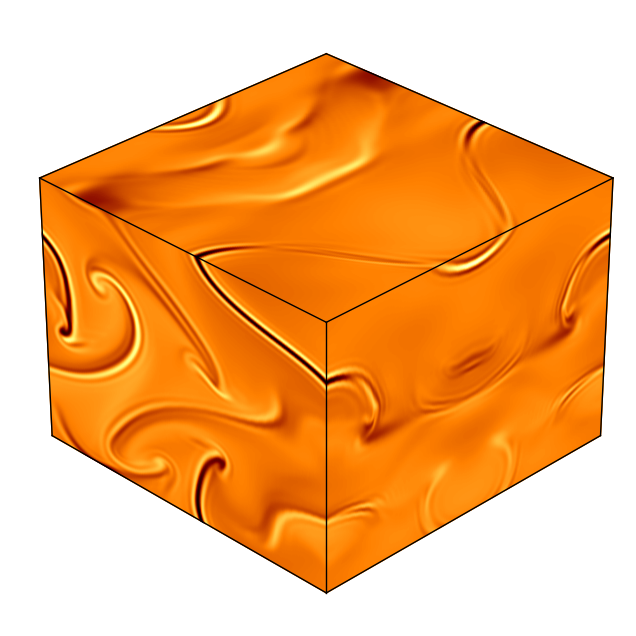

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(np.full_like(X, L), X, Y, 
                facecolors=color_data_XY, 
                shade=False, rstride=1, cstride=1)

ax.plot_surface(X, np.full_like(X, L), Y, 
                facecolors=color_data_YZ, 
                shade=False, rstride=1, cstride=1)

ax.plot_surface(X, Y, np.full_like(X, L), 
                facecolors=color_data_XZ, 
                shade=False, rstride=1, cstride=1)

# 4. Clean up the view
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.view_init(elev=30, azim=45) # Adjust these angles to see the box properly
ax.set_axis_off() # Removes the grey background and grid lines

edges = [
        # Bottom square
        ([0, L, L, 0, 0], [0, 0, L, L, 0], [0, 0, 0, 0, 0]),
        # Top square
        ([0, L, L, 0, 0], [0, 0, L, L, 0], [L, L, L, L, L]),
        # Vertical pillars
        ([0, 0], [0, 0], [0, L]),
        ([L, L], [0, 0], [0, L]),
        ([L, L], [L, L], [0, L]),
        ([0, 0], [L, L], [0, L])
    ]
    #for x_edge, y_edge, z_edge in edges:
    #    ax.plot(x_edge, y_edge, z_edge, color='black', linewidth=1.5, zorder=10)
#plt.savefig(snap_path+"3D_"+str(isnap).zfill(3)+".png")
#plt.close('all')
ax.plot([0,L],[L,L],[L,L],'k',linewidth=1,zorder=10)
ax.plot([0,L],[0,0],[L,L],'k',linewidth=1,zorder=10)
ax.plot([0,L],[L,L],[0,0],'k',linewidth=1,zorder=10)

ax.plot([0,0],[0,L],[L,L],'k',linewidth=1,zorder=10)
ax.plot([L,L],[0,L],[0,0],'k',linewidth=1,zorder=10)
ax.plot([L,L],[0,L],[L,L],'k',linewidth=1,zorder=10)

ax.plot([L,L],[0,0],[0,L],'k',linewidth=1,zorder=10)
ax.plot([L,L],[L,L],[0,L],'k',linewidth=1,zorder=10)
ax.plot([0,0],[L,L],[0,L],'k',linewidth=1,zorder=10)



plt.show()